In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)
import joblib

from xgboost import XGBClassifier
import warnings

warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("../data/preprocessed/churn_cleaned.csv")

In [44]:
from sklearn.preprocessing import FunctionTransformer

def create_tenure_group(df):
    df = df.copy()

    df["Tenure Group"] = pd.cut(
        df["Tenure Months"],
        bins=[-1, 12, 24, 48, float("inf")],
        labels=["0-12", "13-24", "25-48", "49+"]
    )

    return df

tenure_transformer = FunctionTransformer(
    create_tenure_group,
    validate=False
)

In [45]:
X = df.drop("Churn Label", axis=1)
y = df["Churn Label"].map({"No": 0, "Yes": 1})

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [47]:
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()

categorical_features.append("Tenure Group")

In [49]:
preprocessor = ColumnTransformer(
    transformers=[('num','passthrough',numeric_features),
    ('cat',OneHotEncoder(handle_unknown='ignore'),categorical_features)]
)

In [50]:
final_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=1.0,
    colsample_bytree=1.0,
    eval_metric="logloss",
    random_state=42
)

In [51]:
final_pipeline = Pipeline([
    ("tenure_group", tenure_transformer),
    ("preprocessor", preprocessor),
    ("classifier", final_xgb)
])

In [52]:
final_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tenure_group', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['Senior Citizen','Partner','Dependents',...,'Monthly Charges', 'Total Charges','Tenure Group']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function cre...002BA813719B0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False


In [53]:
y_prob = final_pipeline.predict_proba(X_test)[:, 1]

THRESHOLD = 0.40

y_pred = (y_prob >= THRESHOLD).astype(int)

In [54]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.7934705464868701
Precision: 0.5990453460620525
Recall: 0.6711229946524064
F1-Score: 0.6330390920554855
ROC-AUC: 0.8540068201193521


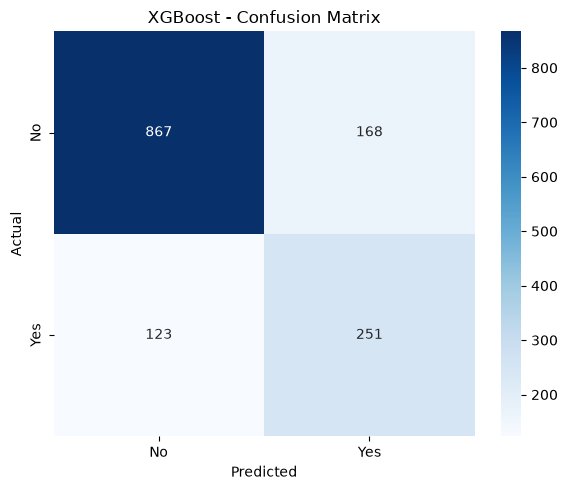

In [55]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"]
)

plt.title("XGBoost - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()

plt.savefig(
    "../images/XGBoost_Confusion_Matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


Save model:

In [57]:
joblib.dump(
    final_pipeline,
    "../src/churn_xgb_pipeline.pkl"
)

['../src/churn_xgb_pipeline.pkl']

Testing Saved model:

In [58]:
loaded_pipeline = joblib.load(
    "../src/churn_xgb_pipeline.pkl"
)

In [60]:
test_predictions = loaded_pipeline.predict(X_test)
test_probabilities = loaded_pipeline.predict_proba(X_test)[:, 1]

print(test_probabilities[:10])
print(test_predictions[:10])

[0.03757683 0.7845782  0.13366376 0.5029188  0.00721653 0.6170055
 0.49369937 0.06579848 0.00170651 0.42869467]
[0 1 0 1 0 1 0 0 0 0]


In [61]:
test_probabilities = loaded_pipeline.predict_proba(X_test)[:, 1]

test_predictions_040 = (test_probabilities >= 0.40).astype(int)

print(test_predictions_040[:10])

[0 1 0 1 0 1 1 0 0 1]
